<a href="https://colab.research.google.com/github/musabegumm/DSC110/blob/main/ML_Model_Building.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Model Building**

# Part 1: Concepts
Linear Regression

In [2]:
#This is training the Linear Regression model to predict values.
import pandas as pd
from sklearn.linear_model import LinearRegression

X = pd.DataFrame({'age': [20, 30, 40, 50, 60]})
y = [110, 115, 120, 125, 130]

lr = LinearRegression()
lr.fit(X, y)

ages_to_predict = pd.DataFrame({'age': [10, 45, 80]})
predictions = lr.predict(ages_to_predict)
print(predictions)

[105.  122.5 140. ]


In [4]:
#Use loop to print predictions cleanly (with 2 decimals)

#This prints each prediction on its own line with rounded to 2 decimals (like: 105.00)
for p in predictions:
    print(f"{p:.2f}")

105.00
122.50
140.00


In [7]:
#Let's apply linear regression when the output is binary (0 and 1)

#Here the model calculates the best fit line
X = pd.DataFrame({'age': [20, 30, 40, 50, 60, 70]})
y = [0, 0, 0, 1, 1, 1]

lr = LinearRegression()
lr.fit(X, y)

ages_to_predict = pd.DataFrame({'age': [5, 45, 100]})
predictions = lr.predict(ages_to_predict)

for p in predictions:
    print(f"{p:.2f}")

-0.53
0.50
1.91


# Logistic Regression:
to make predictions between 0 and 1 for binary outcomes

In [9]:
#Logistic regression
#This puts all the oputputs between 0 & 1 making it a yes or no issue.
from sklearn.linear_model import LogisticRegression
import numpy as np

X = pd.DataFrame({'age': [20, 30, 40, 50, 60, 70]})
y =                       [0,  0,  0,  1,  1,  1]

lr = LogisticRegression()
lr.fit(X, y)

ages_to_predict = pd.DataFrame({'age': [5, 45, 100]})

probabilities = lr.predict_proba(ages_to_predict)

for p in probabilities[:, 1]:
    print(f"{p:.2f}")

0.00
0.50
1.00


In [11]:
#Logistic regression when the outcome is not linear
#I believe this is not as a reliable since it can mess up the predictions leading to unreliable data.
from sklearn.linear_model import LogisticRegression
import pandas as pd

X = pd.DataFrame({'age': [20, 30, 40, 50, 60, 70, 80]})
y =  [0,  0,  1,  1,  1,  0,  0]

lr = LogisticRegression()
lr.fit(X, y)

ages_to_predict = pd.DataFrame({'age': [25, 50, 75]})
probabilities = lr.predict_proba(ages_to_predict)

for p in probabilities[:, 1]:
    print(f"{p:.2f}")


0.43
0.43
0.43


# Decision Tree

In [12]:
#Decision Tree splits data by rules
from sklearn.tree import DecisionTreeClassifier

X = pd.DataFrame({'age': [20, 30, 40, 50, 60, 70, 80]})
y =  [0,  0,  1,  1,  1,  0,  0]

dt = DecisionTreeClassifier()
dt.fit(X, y)

ages_to_predict = pd.DataFrame({'age': [25, 50, 75]})
probabilities = dt.predict(ages_to_predict)

for p in probabilities:
    print(f"{p:.2f}")

0.00
1.00
0.00


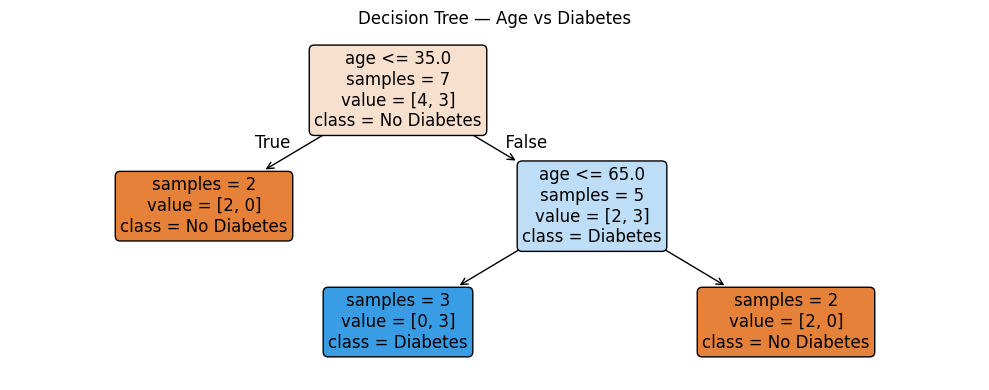

In [13]:
#Visualize the Decision Tree (DEMO only)
#Visualize the tree (demo only)
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Visualize the tree
plt.figure(figsize=(10, 4))

plot_tree(dt,
          feature_names=['age'],
          class_names=['No Diabetes', 'Diabetes'],
          filled=True,
          rounded=True,
          fontsize=12,
          impurity=False,
          precision=0)
plt.title('Decision Tree — Age vs Diabetes')
plt.tight_layout()
plt.show()

# **Part 2: NHANES dataset**

In [14]:
#Here we're setting multiple ML to go againast eachother
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

In [16]:
X_train = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/X_train.csv')
X_test = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/X_test.csv')
y_train = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/y_train.csv')
y_test = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/y_test.csv')

#to prevent warning, converting the y from df to 1d series
y_train = y_train.squeeze()
y_test  = y_test.squeeze()

In [18]:
#Verifiying files via a loop
#Making sure that all the files are being downloaded correctly
files = ['X_train','X_test','y_train','y_test']

for file_name in files:
  # Access the actual DataFrame object using its name from the global scope
  df = globals()[file_name]
  print(df.shape)

(6018, 15)
(1505, 15)
(6018,)
(1505,)


In [20]:
#Verifiying files via a loop
#Printing it
files = ['X_train','X_test','y_train','y_test']

for file_name in files:
  # Access the actual DataFrame object using its name from the global scope
  df = globals()[file_name]
  print(df.shape)

(6018, 15)
(1505, 15)
(6018,)
(1505,)


# Logistic Regression

In [21]:
#fit is the keyword
lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

In [22]:
#Picking one patient to see their actual and predicted value
patient = X_test.iloc[[243]]
patient

,age,bmi,height_cm,systolic_bp,gender_Male,race_ethnicity_Black,race_ethnicity_Mexican American,race_ethnicity_Other,race_ethnicity_Other Hispanic,race_ethnicity_White,education_College grad,education_Do not know,education_High school,education_Less than 9th,education_Some college
243,0.776425,1.479961,-0.391115,1.444984,False,False,False,False,False,True,False,False,True,False,False


In [24]:
#Seeing the actual label for the same patient: #1 means the patient has diabetes
actual = y_test.iloc[243]
print(actual)

1


In [25]:
#Seeing what the logistic regression model did for this patient
prediction = lr.predict(patient)[0]
print(prediction)

0


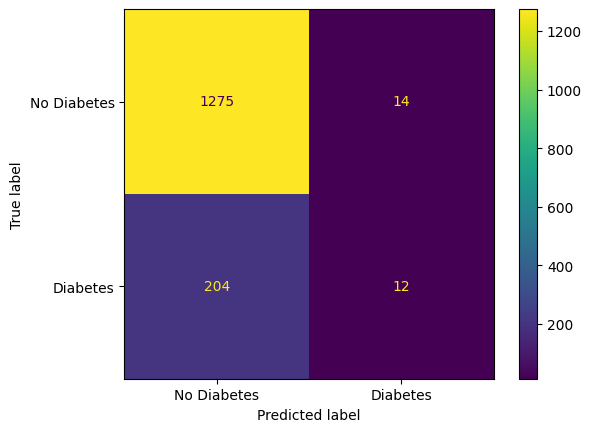

In [26]:
#Seeing this for all patients: done through what's called "Confusion Matrix"
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = lr.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['No Diabetes', 'Diabetes'])
plt.show()

# Decision Tree

In [27]:
dt = DecisionTreeClassifier(random_state=42) #random state used for reproducibility
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [28]:
#Predicting the outcome for the same patient we picked in the top
prediction = dt.predict(patient)[0]
print(prediction)

0


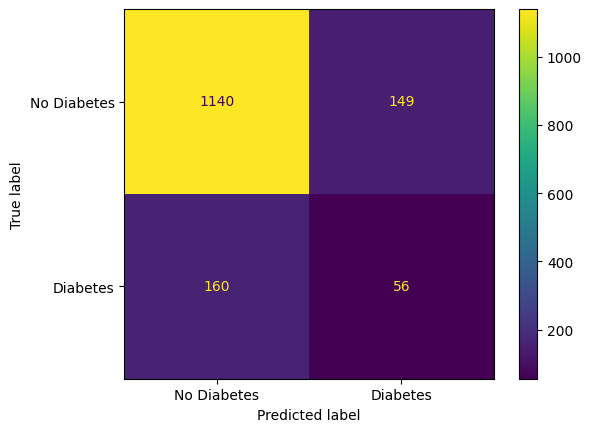

In [29]:
y_pred = dt.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['No Diabetes', 'Diabetes'])
plt.show()

# Random Forest

In [30]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [31]:
prediction = rf.predict(patient)[0]
print(prediction)

1


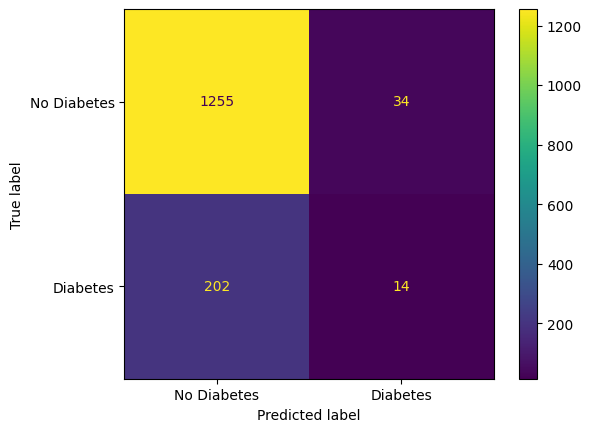

In [32]:
y_pred = rf.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['No Diabetes', 'Diabetes'])
plt.show()


# XGBoost:
builds one trees at a time, each time correcting the mistake of the previous one

In [35]:
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [36]:
prediction = xgb.predict(patient)[0]
print(prediction)


1


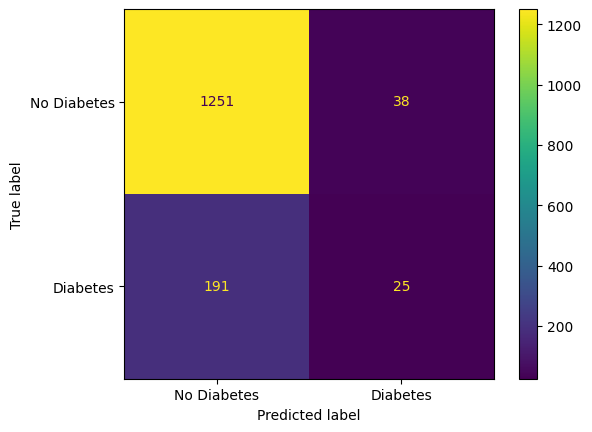

In [37]:
y_pred = xgb.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['No Diabetes', 'Diabetes'])
plt.show()

# Neural Networks

In [38]:
nn = MLPClassifier(random_state=42, max_iter=500)
nn.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(max_iter=500, random_state=42)

In [39]:
prediction = nn.predict(patient)[0]
print(prediction)


0


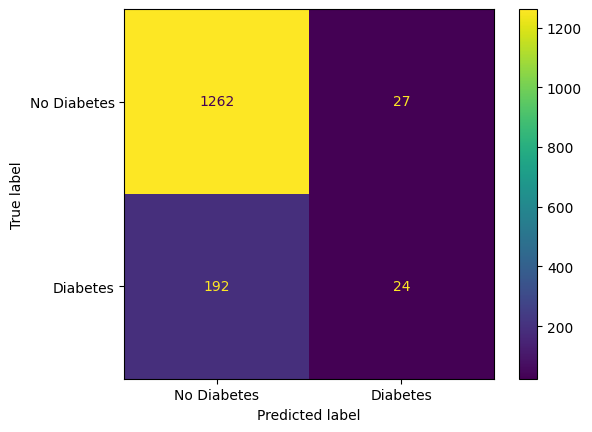

In [40]:
y_pred = nn.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['No Diabetes', 'Diabetes'])
plt.show()
